### Build a Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # Reducer

In [2]:
class State(TypedDict):
    # Messages have the type "list". The add_messages function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list rather tha overwriting them)
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")

In [5]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10d8ff620>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10db141a0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10da46490>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10da46e90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)
## Add Node
graph_builder.add_node("llmchatbot", chatbot)
## Add Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

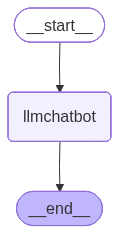

In [10]:
## Visualize the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
response = graph.invoke({"messages": "Hi"})

In [12]:
response["messages"][-1].content

'How can I assist you today?'

In [13]:
for event in graph.stream({"messages": "Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm functioning properly, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here to help you with any questions or tasks you have. What's on your mind?


### Chatbot with Tools

In [14]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(max_results=2)
tavily.invoke("What is langgraph ?")

{'query': 'What is langgraph ?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. It simplifies the development process by enabling the creation of cyclical graphs, which are essential for developing agent r

In [15]:
## Custom function
def multiply(a: int, b: int) -> int:
    """ Multiply a and b

    Args:
        a (int): first int
        b (int): second int
    
    Returns:
        int: output int
    """
    return a * b

In [16]:
tools = [tavily, multiply]

In [17]:
llm_with_tools = llm.bind_tools(tools=tools)

In [18]:
llm_with_tools

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10da46490>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10da46e90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, acc

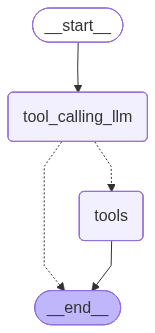

In [19]:
## StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

## Node Definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
    )
builder.add_edge("tools", END)

# compile graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
response = graph.invoke({"messages": "What is the recent AI news?"})

In [21]:
response["messages"][-1].content

'=function=tavily_search>{"query": "recent AI news", "topic": "news", "time_range": "week"}</function>'

In [22]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================

=function=tavily_search>{"query": "recent AI news", "topic": "news", "time_range": "week"}</function>


In [23]:
response = graph.invoke({"messages": "What 5 multiplied by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (6wkbextmn)
 Call ID: 6wkbextmn
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [24]:
response = graph.invoke({"messages": "What 5 multiplied by 2 and then multiply 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What 5 multiplied by 2 and then multiply 10
================================== Ai Message ==================================
Tool Calls:
  multiply (2z23g5sc5)
 Call ID: 2z23g5sc5
  Args:
    a: 5
    b: 2
  multiply (gxjf1dzd4)
 Call ID: gxjf1dzd4
  Args:
    a: 10
    b: 20
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

200


In [25]:
response = graph.invoke({"messages": "What is recent new on AI and 5 multiplied by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is recent new on AI and 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ssbywezvt)
 Call ID: ssbywezvt
  Args:
    query: AI recent news
    time_range: day
    topic: news
  multiply (mn7b2gm86)
 Call ID: mn7b2gm86
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "AI recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://news.bloomberglaw.com/legal-exchange-insights-and-commentary/kentucky-lawsuit-offers-blueprint-for-states-to-sue-ai-chatbots", "title": "Kentucky Lawsuit Offers Blueprint for States to Sue AI Chatbots - Bloomberg Law News", "score": 0.9666631, "published_date": "Tue, 05 May 2026 08:30:09 GMT", "content": "* A recent state lawsuit against a service with an AI chatbot, com

### ReACT Agent Architecture

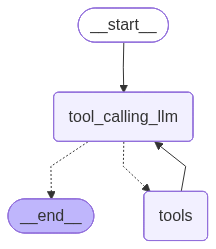

In [26]:
## StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

## Node Definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
    )
builder.add_edge("tools", "tool_calling_llm")

# compile graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
response = graph.invoke({"messages": "What is recent new on AI and 5 multiplied by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is recent new on AI and 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (6pq24vz8z)
 Call ID: 6pq24vz8z
  Args:
    query: AI recent news
    search_depth: advanced
    topic: news
  multiply (h1n31dj9e)
 Call ID: h1n31dj9e
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "AI recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.mitsloanme.com/article/ai-compute-costs-exceed-workforce-costs-nvidia-executive-says/", "title": "AI Compute Costs Exceed Workforce Costs, Nvidia Executive Says - MIT Sloan Management Review Middle East", "score": 0.8489722, "published_date": "Wed, 29 Apr 2026 13:27:28 GMT", "content": "Twitter  Facebook  Whatsapp  Linkedin\n\n- #### News\n\n  1. Oman to Scale

### Adding Memory In Agentic Graph

In [31]:
response=graph.invoke({"messages":"Hello my name is Ashwani"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ashwani
================================== Ai Message ==================================

Nice to meet you, Ashwani. Is there anything I can help you with today?


In [32]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have any information about your name. If you'd like to share it with me, I'd be happy to chat with you about it!


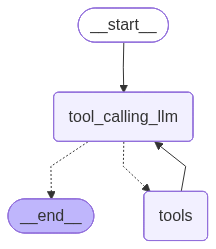

In [33]:
## StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node Definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
    )
builder.add_edge("tools", "tool_calling_llm")

# compile graph
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
config = {"configurable": {"thread_id": "thread_1"}}

response = graph.invoke({"messages": "Hi, My name is Ashwani"}, config=config)
response

{'messages': [HumanMessage(content='Hi, My name is Ashwani', additional_kwargs={}, response_metadata={}, id='31e0f9cb-8750-4c9a-81cb-28b09cc7f464'),
  AIMessage(content='Nice to meet you, Ashwani. Is there anything I can help you with today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1753, 'total_tokens': 1773, 'completion_time': 0.030140034, 'completion_tokens_details': None, 'prompt_time': 0.130717615, 'prompt_tokens_details': None, 'queue_time': 0.027516489, 'total_time': 0.160857649}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_8639719ff2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df774-825a-7dd0-8f5d-71ec9991b58e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1753, 'output_tokens': 20, 'total_tokens': 1773})]}

In [35]:
response["messages"][-1].content

'Nice to meet you, Ashwani. Is there anything I can help you with today?'

In [36]:
response = graph.invoke({"messages": "Hey, do you remember my name"},config= config)
response["messages"][-1].content

'Your name is Ashwani.'

### Streaming

In [37]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [38]:
def superbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

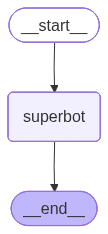

In [39]:
graph = StateGraph(State)

## node
graph.add_node("superbot", superbot)

## edges
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

## display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [40]:
## Invocation

config = {"configurable": {"thread_id": "thread_1"}}

graph_builder.invoke({'messages':"Hi,My name is Ashwani And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Ashwani And I like cricket', additional_kwargs={}, response_metadata={}, id='e89661b8-852f-4d12-bc83-b22491705eb6'),
  AIMessage(content='Nice to meet you, Ashwani. Cricket is a fantastic sport. Are you a fan of any particular team or player? Do you enjoy watching international matches or follow local leagues like the Indian Premier League (IPL) or the Big Bash League (BBL)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 47, 'total_tokens': 102, 'completion_time': 0.100693462, 'completion_tokens_details': None, 'prompt_time': 0.002263006, 'prompt_tokens_details': None, 'queue_time': 0.0686772, 'total_time': 0.102956468}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e09ee421cf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df782-06d0-7dd0-8fd6-81d87676cade-0', tool_calls=[], invalid_tool_calls=[], 

### Streaming

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.


In [41]:
# Create a thread
config = {"configurable": {"thread_id": "thread_3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Ashwani And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Nice to meet you, Ashwani! Cricket is a fantastic sport, with a rich history and a massive following around the world. Which team or player is your favorite in international cricket? Are you more into Test cricket, One-Day Internationals (ODIs), or Twenty20 (T20) cricket?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 47, 'total_tokens': 111, 'completion_time': 0.095529766, 'completion_tokens_details': None, 'prompt_time': 0.003238646, 'prompt_tokens_details': None, 'queue_time': 0.020235504, 'total_time': 0.098768412}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6a1eabf260', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df78e-1ce4-76f2-b2d4-2faf593eef1c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 64, 'total_tokens': 111})]}}


In [42]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Ashwani And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Ashwani And I like cricket', additional_kwargs={}, response_metadata={}, id='e9d886b3-c6b7-46ca-a974-c076152fdf4e'), AIMessage(content='Nice to meet you, Ashwani! Cricket is a fantastic sport, with a rich history and a massive following around the world. Which team or player is your favorite in international cricket? Are you more into Test cricket, One-Day Internationals (ODIs), or Twenty20 (T20) cricket?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 47, 'total_tokens': 111, 'completion_time': 0.095529766, 'completion_tokens_details': None, 'prompt_time': 0.003238646, 'prompt_tokens_details': None, 'queue_time': 0.020235504, 'total_time': 0.098768412}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6a1eabf260', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df78e-1ce4-76f2-b2d4-2faf593eef1c-0', tool_

In [43]:
# Create a thread
config = {"configurable": {"thread_id": "thread_4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm sure you must be a huge fan. Are you from India? India is known for its passionate cricket fans, and the country has produced some of the greatest cricketers of all time, like Sachin Tendulkar and Virat Kohli.\n\nWhat's your favorite aspect of cricket? Is it the fast-paced action of a T20 match, the strategic planning of a Test series, or the art of batting and bowling?\n\nAlso, do you have a favorite cricket team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 45, 'total_tokens': 161, 'completion_time': 0.164792013, 'completion_tokens_details': None, 'prompt_time': 0.003138772, 'prompt_tokens_details': None, 'queue_time': 0.04833776, 'total_time': 0.167930785}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e09ee421cf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model

In [45]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='47d2cc4c-dd7f-4887-b110-af768ed936b6'), AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm sure you must be a huge fan. Are you from India? India is known for its passionate cricket fans, and the country has produced some of the greatest cricketers of all time, like Sachin Tendulkar and Virat Kohli.\n\nWhat's your favorite aspect of cricket? Is it the fast-paced action of a T20 match, the strategic planning of a Test series, or the art of batting and bowling?\n\nAlso, do you have a favorite cricket team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 45, 'total_tokens': 161, 'completion_time': 0.164792013, 'completion_tokens_details': None, 'prompt_time': 0.003138772, 'prompt_tokens_details': None, 'queue_time': 0.04833776, 'total_time': 0.167930785}, 'model_name': 'll

In [46]:
config = {"configurable": {"thread_id": "thread_5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Ashwani and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Ashwani and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019df792-288b-7091-9442-74014f4cb94a', 'metadata': {'thread_id': 'thread_5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Ashwani and I like to play cricket', additional_kwargs={}, response_metadata={}, id='65597153-78c6-4f47-9bee-0884c7630431')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019df792-2901-7373-aea6-8714547cbfd3', 'metadata': {'thread_id': 'thread_5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:b568386c-6049-2e47-97f8-4bf086107485'}, 'parent_ids': ['019df792-288b-7091-9442-74014f4cb94a']}
{'event': 'on_chat_model_start', 'data': {'in